#Retail_Sales_Dataset:

In [76]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [77]:
#loading data in vscode

var = pd.read_csv("retail_sales_dataset.csv")
df = pd.DataFrame(var)
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [79]:
#basic info about data
df.columns
print()
df.shape
print()
df.info()
print()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB



In [80]:
df.columns = df.columns.str.strip().str.lower().str.replace(" " , "_")
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='object')

In [81]:
df["date"] = pd.to_datetime(df["date"])

In [82]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   gender            1000 non-null   object        
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   object        
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB



,transaction_id,date,age,quantity,price_per_unit,total_amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [83]:
#for missing values:
check_missing_values = df.isnull().sum()
check_missing_values

transaction_id      0
date                0
customer_id         0
gender              0
age                 0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64

In [84]:
#for duplicates in dataset we use:

check_duplicates = df.duplicated()
check_duplicates

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [85]:
#For removing duplicates:

df = df.drop_duplicates()
df


,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [275]:
avg_transitions = df["total_amount"].mean()
avg_transitions

456.0

In [86]:
#for yearly sales:

df["year"] = df["date"].dt.year

yearly_sales = df.groupby("year")["total_amount"].sum()
yearly_sales

year
2023    454470
2024      1530
Name: total_amount, dtype: int64

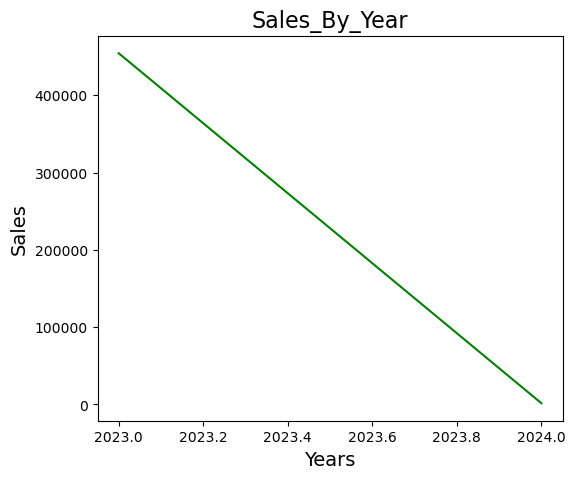

In [149]:

plt.figure(figsize = (6 , 5))
yearly_sales.plot(kind="line" , color= "green")



plt.title("Sales_By_Year" , fontsize = 16)
plt.xlabel("Years" , fontsize = 14)
plt.ylabel("Sales" , fontsize = 14)




plt.show()

In [273]:
df["month"] = df["date"].dt.month_name()

monthly_sales = df.groupby("month")["total_amount"].sum().sort_values(ascending=False)
monthly_sales

month
May          53150
October      46580
December     44690
February     44060
January      36980
August       36960
June         36715
July         35465
November     34920
April        33870
March        28990
September    23620
Name: total_amount, dtype: int64

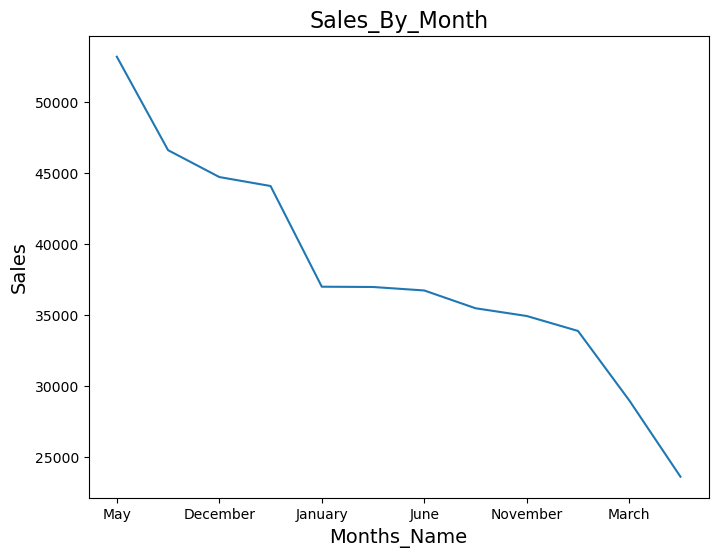

In [89]:
plt.figure(figsize=(8 , 6))
monthly_sales.plot(kind="line")

plt.title("Sales_By_Month" , fontsize = 16)
plt.xlabel("Months_Name" , fontsize = 14)
plt.ylabel("Sales" , fontsize = 14)


plt.show()

In [90]:
df["day"] = df["date"].dt.day_name()

daily_sales = df.groupby("day")["total_amount"].sum()
daily_sales

day
Friday       66290
Monday       70250
Saturday     78815
Sunday       58600
Thursday     53835
Tuesday      69440
Wednesday    58770
Name: total_amount, dtype: int64

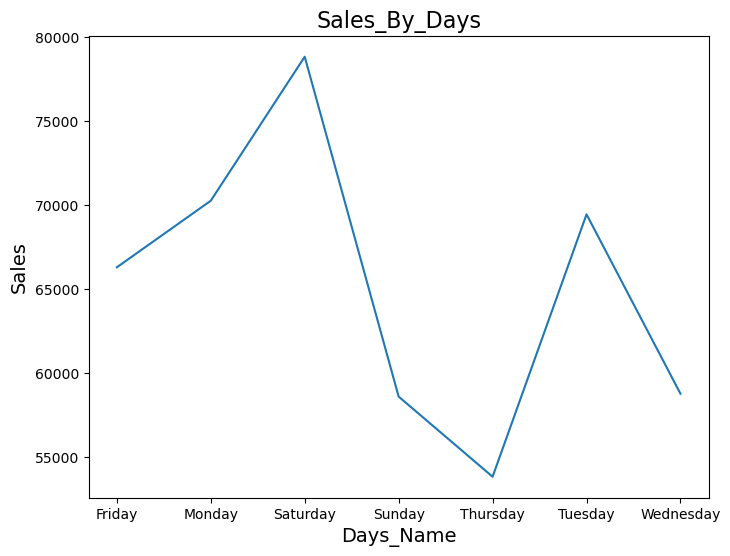

In [147]:
plt.figure(figsize=(8 , 6))
daily_sales.plot(kind="line")


plt.title("Sales_By_Days" , fontsize = 16)
plt.xlabel("Days_Name" , fontsize = 14)
plt.ylabel("Sales" , fontsize = 14)


plt.show()

In [102]:
product_count = df["product_category"].value_counts(ascending=False)
product_count

product_category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

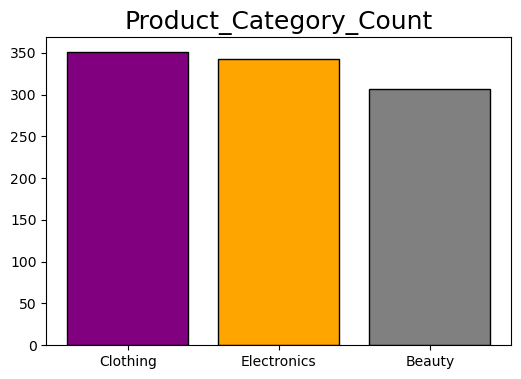

In [255]:
plt.figure(figsize=(6 , 4))
c = ['purple' , "orange" , "gray"]
plt.bar(product_count.index , product_count.values , edgecolor = "black" , color = c)




plt.title("Product_Category_Count" , fontsize = 18)
plt.xlabel("")



plt.show()

In [115]:
best_selling_product = df.groupby("product_category")["total_amount"].sum().sort_values(ascending=False)
best_selling_product

product_category
Electronics    156905
Clothing       155580
Beauty         143515
Name: total_amount, dtype: int64

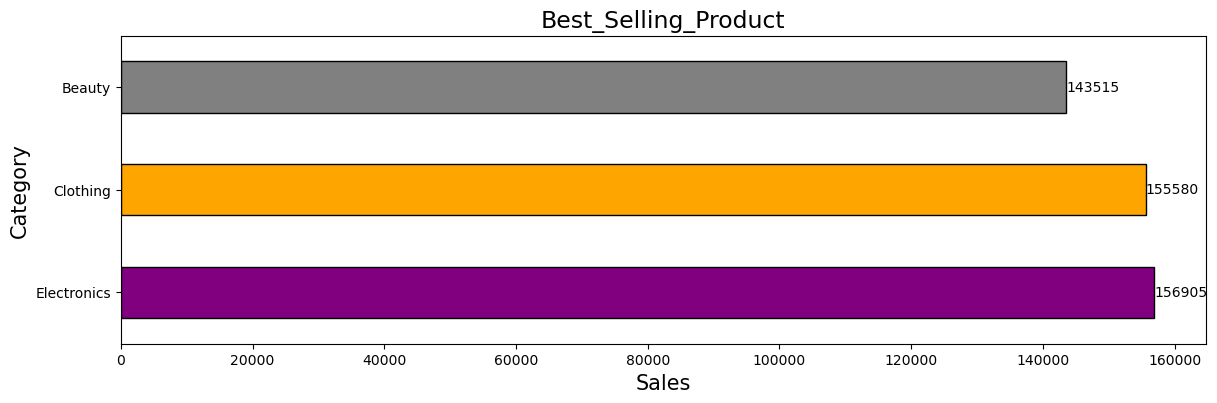

In [142]:
plt.figure(figsize=(14 , 4))
c = ["purple" , "orange" , "gray"]
ax = best_selling_product.plot(kind="barh" , edgecolor = "black" , color = c)
ax.bar_label(ax.containers[0])


plt.title("Best_Selling_Product" , fontsize = 17)
plt.xlabel("Sales" , fontsize = 15)
plt.ylabel("Category" , fontsize = 15)



plt.show()

In [256]:
product_quantity = df.groupby("product_category")["quantity"].sum().sort_values(ascending=False)
product_quantity

product_category
Clothing       894
Electronics    849
Beauty         771
Name: quantity, dtype: int64

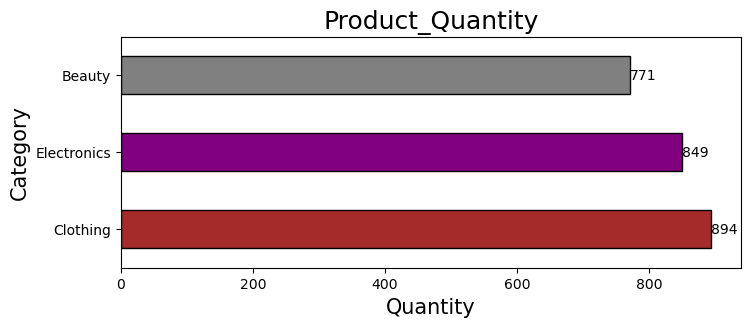

In [258]:
plt.figure(figsize=(8 , 3))
c = ["brown" , "purple" , "gray"]
ax = product_quantity.plot(kind="barh" , edgecolor = "black" , color=c)
ax.bar_label(ax.containers[0])

plt.title("Product_Quantity" , fontsize = 18)
plt.xlabel("Quantity" , fontsize = 15)
plt.ylabel("Category" , fontsize = 15)



plt.show()

In [259]:
Sales_by_Customer = df.groupby("customer_id")["total_amount"].sum()
Sales_by_Customer

customer_id
CUST001     150
CUST002    1000
CUST003      30
CUST004     500
CUST005     100
           ... 
CUST995      30
CUST996      50
CUST997      90
CUST998     100
CUST999     150
Name: total_amount, Length: 1000, dtype: int64

In [158]:
Top_Sales_by_Customer = Sales_by_Customer.sort_values(ascending=False).head(10)
Top_Sales_by_Customer

customer_id
CUST487    2000
CUST476    2000
CUST773    2000
CUST503    2000
CUST093    2000
CUST089    2000
CUST946    2000
CUST157    2000
CUST155    2000
CUST420    2000
Name: total_amount, dtype: int64

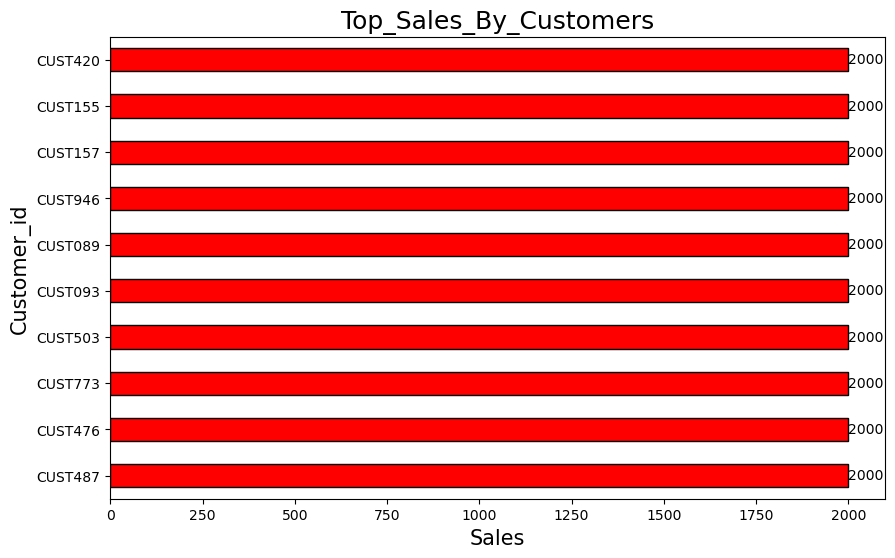

In [162]:
plt.figure(figsize=(10 , 6))
c = ["r"]
ax = Top_Sales_by_Customer.plot(kind="barh" , edgecolor = "black" , color = c)
ax.bar_label(ax.containers[0])

plt.title("Top_Sales_By_Customers" , fontsize = 18)
plt.xlabel("Sales", fontsize = 15)
plt.ylabel("Customer_id" , fontsize = 15)



plt.show()

In [170]:
gender_count = df["gender"].value_counts()
gender_count

gender
Female    510
Male      490
Name: count, dtype: int64

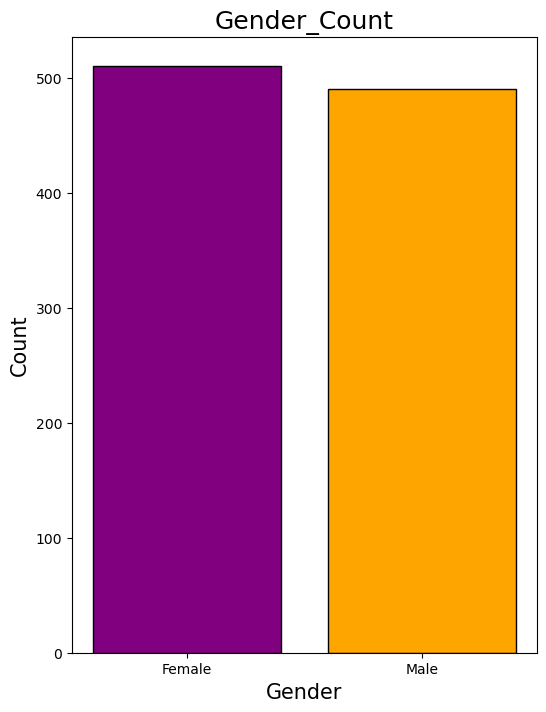

In [266]:
plt.figure(figsize=(6 , 8))
c = ["purple" , "orange"]
plt.bar(gender_count.index , gender_count.values , edgecolor = "black" ,  color = c)

plt.title("Gender_Count" , fontsize = 18)
plt.ylabel("Count" , fontsize = 15)
plt.xlabel("Gender" , fontsize =15)



plt.show()

In [181]:
Sales_by_gender = df.groupby("gender")["total_amount"].sum().sort_values(ascending=False)
Sales_by_gender

gender
Female    232840
Male      223160
Name: total_amount, dtype: int64

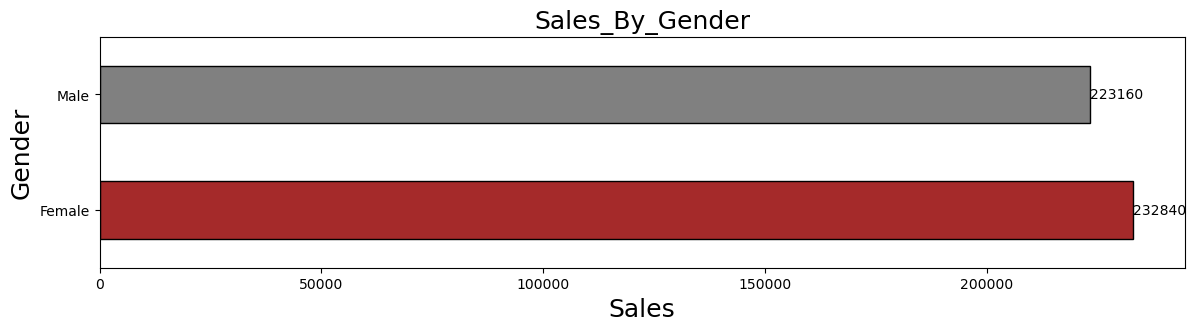

In [190]:
plt.figure(figsize=(14 , 3))
c = ["brown" , "gray"]
ax = Sales_by_gender.plot(kind="barh" , edgecolor = "black" , color = c)
ax.bar_label(ax.containers[0])

plt.title("Sales_By_Gender" , fontsize = 18)
plt.xlabel("Sales", fontsize = 18)
plt.ylabel("Gender", fontsize = 18)


plt.show()

In [228]:
age_count = df["age"].value_counts(ascending=False)
age_count

age
43    31
64    31
57    30
51    30
34    28
54    28
22    27
62    27
42    26
47    26
46    25
23    24
40    24
50    23
27    23
52    22
60    22
30    22
26    22
31    22
35    22
28    21
41    21
18    21
55    21
20    21
19    21
21    20
25    20
49    19
56    19
32    19
38    19
61    18
39    18
48    18
63    17
45    17
59    17
53    17
29    16
37    16
36    15
44    15
24    15
58    14
33    10
Name: count, dtype: int64

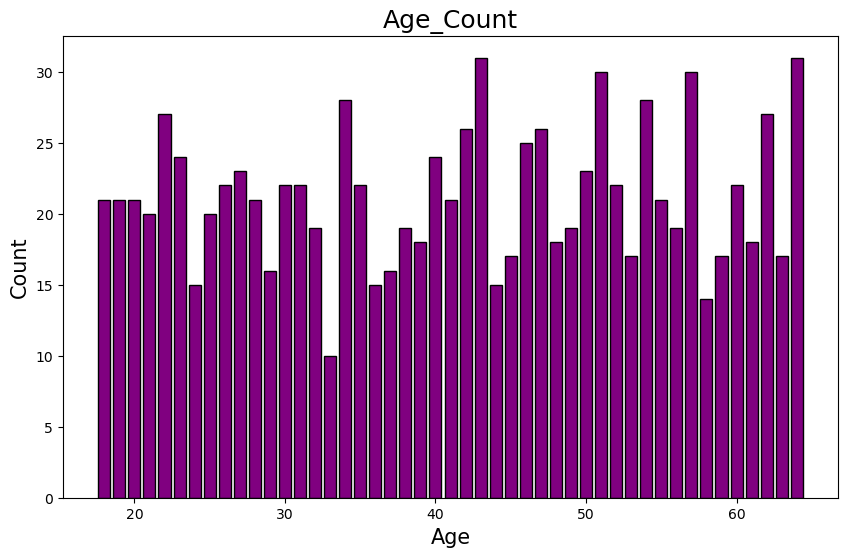

In [264]:
plt.figure(figsize=(10, 6))
c = ["purple"]
plt.bar(age_count.index, age_count.values , edgecolor = "black"  ,  color =c)

plt.title("Age_Count" , fontsize = 18)
plt.xlabel("Age" , fontsize = 15)
plt.ylabel("Count" , fontsize = 15)

plt.show()

In [212]:
Sales_By_age =df.groupby("age")["total_amount"].sum()
Sales_By_age

age
18    11215
19    14870
20     8645
21    12585
22    13700
23     8220
24     5415
25     9900
26    13980
27     9385
28     8670
29     6570
30     9790
31    10220
32     5550
33     6240
34    16785
35    11290
36     9105
37    11650
38    11100
39     4595
40     9415
41     5650
42     8500
43    17970
44     7560
45     6325
46    13090
47    12505
48     7240
49     5110
50     9845
51    16065
52     7040
53     9510
54    10505
55     9780
56     9440
57     9290
58     7395
59     9470
60    11590
61     6730
62     8120
63     9250
64     9125
Name: total_amount, dtype: int64

In [239]:
Top_Sales_By_age = Sales_By_age.sort_values(ascending=False).head(10)
Top_Sales_By_age

age
43    17970
34    16785
51    16065
19    14870
26    13980
22    13700
46    13090
21    12585
47    12505
37    11650
Name: total_amount, dtype: int64

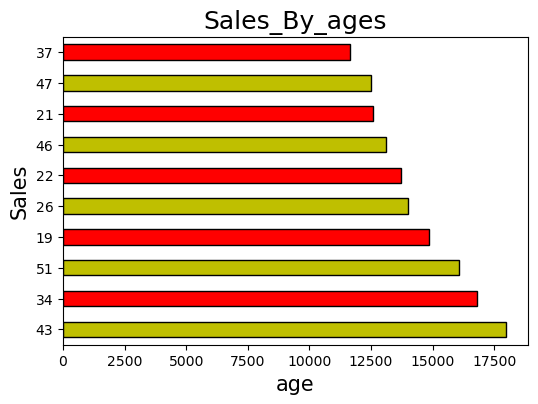

In [241]:
plt.figure(figsize=(6 , 4))
c = ["y" , "r"]
Top_Sales_By_age.plot(kind="barh" , edgecolor = "black" , color = c)


plt.title("Sales_By_ages" , fontsize = 18)
plt.xlabel("age" , fontsize= 15)
plt.ylabel("Sales" , fontsize = 15)

plt.show()

In [270]:
correlation = df["quantity"].corr(df["total_amount"])

correlation

0.37370705412140603

#quantity or total_amount ka kuch khas relation nai ha apas ma

In [271]:
Sales_By_Quantity = df.groupby("quantity")["total_amount"].mean()
Sales_By_Quantity

quantity
1    177.094862
2    333.539095
3    598.692946
4    706.692015
Name: total_amount, dtype: float64

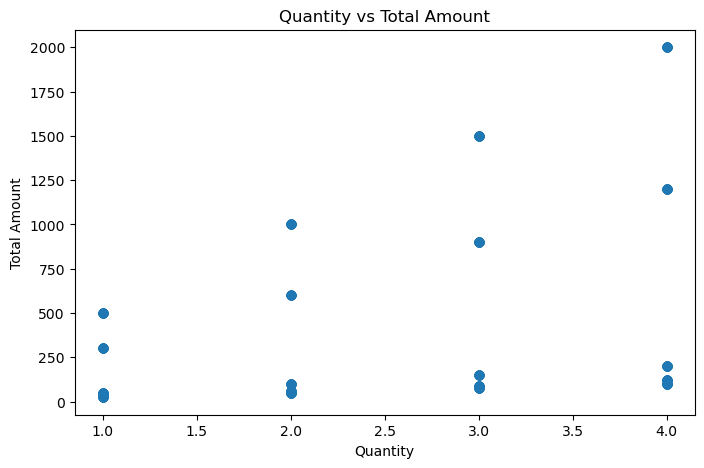

In [272]:
plt.figure(figsize=(8, 5))

plt.scatter(df["quantity"], df["total_amount"])

plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")

plt.show()